In [1]:
import os
import sys
import re
import warnings
import pickle
import json
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

DATA_PATH = project_root / 'data' / 'raw' / 'IEEE_PHM' / 'dataset'
PROCESSED_DIR = project_root / 'data' / 'processed' / 'ieee_phm'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Data path: {DATA_PATH}")

Project root: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel
Data path: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/data/raw/IEEE_PHM/dataset


In [2]:
@dataclass
class PHMConfig:
    root_dir: str = str(DATA_PATH)
    seq_len: int = 64
    stride_train: int = 4        # was 1 → reduce 98% overlap to ~94%, less pseudo-replication
    stride_eval: int = 1
    batch_size: int = 64
    
    # Vibration params
    vibration_fs: float = 25600.0
    record_interval_sec: float = 10.0
    
    # FFT
    add_fft: bool = True
    fft_bands_hz: Tuple[Tuple[float, float], ...] = (
        (0, 500), (500, 1000), (1000, 2500),
        (2500, 5000), (5000, 10000), (10000, 12800),
    )
    
    # Target
    rul_cap_sec: float = 1500.0   # ← CRITICAL: cap RUL so model focuses on degradation zone
    target_transform: str = "log1p_standard"  # "none" | "standard" | "log1p_standard"
    
    # Trend / degradation features
    trend_windows: Tuple[int, ...] = (10, 30)   # rolling window sizes (in records)
    trend_features: Tuple[str, ...] = (
        "h_rms", "v_rms", "h_kurtosis", "v_kurtosis",
        "h_crest", "v_crest", "h_p2p", "v_p2p",
        "h_total_energy", "v_total_energy",
        "temp_mean",
    )
    baseline_n: int = 10  # number of initial records for healthy-state baseline
    
    # Splits (PHM2012 challenge convention)
    train_bearings: List[str] = field(default_factory=lambda: [
        "Bearing1_1", "Bearing1_2", "Bearing2_1", "Bearing2_2",
        "Bearing3_1", "Bearing3_2",
    ])
    val_bearings: List[str] = field(default_factory=lambda: [
        "Bearing1_3", "Bearing2_3",
    ])
    test_bearings: List[str] = field(default_factory=lambda: [
        "Bearing1_4", "Bearing1_5", "Bearing1_6", "Bearing1_7",
        "Bearing2_4", "Bearing2_5", "Bearing2_6", "Bearing2_7",
        "Bearing3_3",
    ])
    
    seed: int = 42

cfg = PHMConfig()
print("Config created.")
print(f"  RUL cap:       {cfg.rul_cap_sec}s")
print(f"  Train stride:  {cfg.stride_train}")
print(f"  Trend windows: {cfg.trend_windows}")
print(f"  Trend features:{len(cfg.trend_features)}")

Config created.
  RUL cap:       1500.0s
  Train stride:  4
  Trend windows: (10, 30)
  Trend features:11


In [3]:
_ACC_RE = re.compile(r"acc_(\d+)\.csv$", re.IGNORECASE)
_TEMP_RE = re.compile(r"temp_(\d+)\.csv$", re.IGNORECASE)

def _safe_read_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, header=None, engine="python", sep=None)

def _seconds_from_hmsu(df, h, m, s, us):
    hh = pd.to_numeric(df.iloc[:, h], errors="coerce").to_numpy(float)
    mm = pd.to_numeric(df.iloc[:, m], errors="coerce").to_numpy(float)
    ss = pd.to_numeric(df.iloc[:, s], errors="coerce").to_numpy(float)
    uu = pd.to_numeric(df.iloc[:, us], errors="coerce").to_numpy(float)
    return hh * 3600.0 + mm * 60.0 + ss + uu * 1e-6

def _basic_stats(x: np.ndarray, prefix: str) -> Dict[str, float]:
    x = np.asarray(x, dtype=np.float64)
    if x.size == 0:
        keys = ["mean","std","rms","p2p","abs_mean","skew","kurtosis","crest"]
        return {f"{prefix}_{k}": np.nan for k in keys}
    mean = float(np.mean(x))
    std = float(np.std(x))
    rms = float(np.sqrt(np.mean(np.square(x))))
    p2p = float(np.max(x) - np.min(x))
    abs_mean = float(np.mean(np.abs(x)))
    if std < 1e-12:
        skew, kurt = 0.0, 0.0
    else:
        z = (x - mean) / std
        skew = float(np.mean(z ** 3))
        kurt = float(np.mean(z ** 4) - 3.0)
    crest = float(np.max(np.abs(x)) / (rms + 1e-12))
    return {
        f"{prefix}_mean": mean, f"{prefix}_std": std,
        f"{prefix}_rms": rms, f"{prefix}_p2p": p2p,
        f"{prefix}_abs_mean": abs_mean, f"{prefix}_skew": skew,
        f"{prefix}_kurtosis": kurt, f"{prefix}_crest": crest,
    }

def _fft_band_energies(x, fs, bands, prefix):
    x = np.asarray(x, dtype=np.float64)
    if x.size == 0:
        out = {}
        for lo, hi in bands:
            out[f"{prefix}_band_{int(lo)}_{int(hi)}_energy"] = np.nan
        out[f"{prefix}_total_energy"] = np.nan
        out[f"{prefix}_dom_freq_hz"] = np.nan
        return out
    x = x - np.mean(x)
    spec = np.fft.rfft(x)
    psd = (np.abs(spec) ** 2) / max(len(x), 1)
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    total = float(np.sum(psd) + 1e-12)
    out = {}
    for lo, hi in bands:
        mask = (freqs >= lo) & (freqs < hi)
        e = float(np.sum(psd[mask]))
        out[f"{prefix}_band_{int(lo)}_{int(hi)}_energy"] = e / total  # relative only
    out[f"{prefix}_total_energy"] = total
    if len(psd) > 1:
        idx = int(np.argmax(psd[1:]) + 1)
        out[f"{prefix}_dom_freq_hz"] = float(freqs[idx])
    else:
        out[f"{prefix}_dom_freq_hz"] = 0.0
    return out

def extract_vibration_features(acc_file: Path, cfg: PHMConfig) -> Dict[str, Any]:
    df = _safe_read_csv(acc_file)
    if df.shape[1] < 6:
        raise ValueError(f"Unexpected acc format: {acc_file}")
    h = pd.to_numeric(df.iloc[:, 4], errors="coerce").to_numpy(float)
    v = pd.to_numeric(df.iloc[:, 5], errors="coerce").to_numpy(float)
    feat = {}
    feat.update(_basic_stats(h, "h"))
    feat.update(_basic_stats(v, "v"))
    # Cross-channel
    if np.nanstd(h) > 0 and np.nanstd(v) > 0:
        feat["hv_corr"] = float(np.corrcoef(h, v)[0, 1])
    else:
        feat["hv_corr"] = 0.0
    feat["hv_rms_ratio"] = feat["h_rms"] / (feat["v_rms"] + 1e-12)
    if cfg.add_fft:
        feat.update(_fft_band_energies(h, cfg.vibration_fs, cfg.fft_bands_hz, "h"))
        feat.update(_fft_band_energies(v, cfg.vibration_fs, cfg.fft_bands_hz, "v"))
    m = _ACC_RE.search(acc_file.name)
    feat["record_idx"] = int(m.group(1)) if m else -1
    return feat

def extract_temperature(temp_file: Path) -> Dict[str, float]:
    df = _safe_read_csv(temp_file)
    if df.shape[1] < 5:
        raise ValueError(f"Unexpected temp format: {temp_file}")
    temp = pd.to_numeric(df.iloc[:, 4], errors="coerce").to_numpy(float)
    m = _TEMP_RE.search(temp_file.name)
    return {
        "temp_record_idx": int(m.group(1)) if m else -1,
        "temp_mean": float(np.nanmean(temp)) if len(temp) else np.nan,
        "temp_std": float(np.nanstd(temp)) if len(temp) else np.nan,
        "temp_last": float(temp[-1]) if len(temp) else np.nan,
    }

print("Feature extraction functions defined.")

Feature extraction functions defined.


In [4]:
def _add_trend_features(df: pd.DataFrame, cfg: PHMConfig) -> pd.DataFrame:
    """
    Add degradation-aware features PER BEARING:
    - Rolling mean/std over trailing windows (captures recent trend)
    - Delta (1-step difference, captures instantaneous change)
    - Relative-to-baseline (normalizes each bearing to its own healthy state)
    
    These features are what actually allow cross-bearing generalization,
    because degradation *patterns* (rising RMS, rising kurtosis) are
    universal even when absolute levels differ across conditions.
    """
    for feat in cfg.trend_features:
        if feat not in df.columns:
            continue
        
        col = df[feat]
        
        # Rolling statistics over trailing windows
        for w in cfg.trend_windows:
            df[f"{feat}_rmean{w}"] = col.rolling(w, min_periods=1).mean()
            df[f"{feat}_rstd{w}"] = col.rolling(w, min_periods=1).std().fillna(0)
        
        # Delta (1-step change)
        df[f"{feat}_delta"] = col.diff().fillna(0)
        
        # Exponential moving average (smooth trend indicator)
        df[f"{feat}_ema30"] = col.ewm(span=30, min_periods=1).mean()
        
        # Relative to healthy-state baseline (first N records)
        baseline = col.iloc[:min(cfg.baseline_n, len(df))].mean()
        df[f"{feat}_rel_base"] = (col - baseline) / (abs(baseline) + 1e-12)
    
    # Condition one-hot encoding (helps model learn condition-specific patterns)
    for cond in [1, 2, 3]:
        df[f"cond_{cond}"] = (df["condition_id"] == cond).astype(np.float32)
    
    return df


def build_bearing_df(bearing_dir: Path, source: str, cfg: PHMConfig) -> pd.DataFrame:
    """Process one bearing folder into a per-record feature DataFrame."""
    acc_files = sorted(
        [p for p in bearing_dir.glob("acc_*.csv")],
        key=lambda p: int(_ACC_RE.search(p.name).group(1))
    )
    temp_files = sorted(
        [p for p in bearing_dir.glob("temp_*.csv")],
        key=lambda p: int(_TEMP_RE.search(p.name).group(1))
    )
    if len(acc_files) == 0:
        return pd.DataFrame()
    
    rows = []
    for f in acc_files:
        row = extract_vibration_features(f, cfg)
        row["bearing_name"] = bearing_dir.name
        row["source"] = source
        rows.append(row)
    
    df = pd.DataFrame(rows).sort_values("record_idx").reset_index(drop=True)
    df["step_idx"] = np.arange(len(df), dtype=int)
    df["t_rel_sec"] = df["step_idx"] * cfg.record_interval_sec
    
    # Condition from bearing name (e.g. Bearing1_2 -> condition 1)
    m = re.match(r"Bearing(\d+)_\d+", bearing_dir.name)
    df["condition_id"] = int(m.group(1)) if m else -1
    
    # Merge temperature (backward asof join)
    if len(temp_files) > 0:
        temp_rows = [extract_temperature(f) for f in temp_files]
        temp_df = pd.DataFrame(temp_rows).sort_values("temp_record_idx").reset_index(drop=True)
        temp_df["temp_t_rel_sec"] = np.arange(len(temp_df)) * 60.0
        
        df = pd.merge_asof(
            df.sort_values("t_rel_sec"),
            temp_df[["temp_t_rel_sec", "temp_mean", "temp_std", "temp_last"]].sort_values("temp_t_rel_sec"),
            left_on="t_rel_sec", right_on="temp_t_rel_sec",
            direction="backward", allow_exact_matches=True,
        )
        for c in ["temp_mean", "temp_std", "temp_last"]:
            df[c] = df[c].ffill().bfill()
    else:
        df["temp_mean"] = np.nan
        df["temp_std"] = np.nan
        df["temp_last"] = np.nan
    
    # ── ADD TREND / DEGRADATION FEATURES ──
    df = _add_trend_features(df, cfg)
    
    # ── RUL LABEL ──
    if source in {"Learning_set", "Full_Test_Set"}:
        max_t = float(df["t_rel_sec"].max())
        df["rul_sec"] = max_t - df["t_rel_sec"]
    else:
        df["rul_sec"] = np.nan
    
    return df


def build_full_table(cfg: PHMConfig) -> pd.DataFrame:
    root = Path(cfg.root_dir)
    frames = []
    for source in ["Learning_set", "Full_Test_Set", "Test_set"]:
        src_dir = root / source
        if not src_dir.exists():
            continue
        for bdir in sorted([x for x in src_dir.iterdir() if x.is_dir()]):
            print(f"  Processing {source}/{bdir.name}...", end="")
            df = build_bearing_df(bdir, source, cfg)
            if not df.empty:
                frames.append(df)
                print(f" {len(df)} records, {df.shape[1]} cols")
            else:
                print(" EMPTY")
    
    full_df = pd.concat(frames, ignore_index=True)
    full_df = full_df.sort_values(["source", "bearing_name", "step_idx"]).reset_index(drop=True)
    return full_df

print("Building feature table (with trend features)...")
full_df = build_full_table(cfg)
print(f"\nTotal rows: {len(full_df)}")
print(f"Bearings: {full_df['bearing_name'].nunique()}")
print(f"Columns: {full_df.shape[1]}")

Building feature table (with trend features)...
  Processing Learning_set/Bearing1_1...

 2803 records, 125 cols
  Processing Learning_set/Bearing1_2... 871 records, 125 cols
  Processing Learning_set/Bearing2_1... 911 records, 125 cols
  Processing Learning_set/Bearing2_2... 797 records, 124 cols
  Processing Learning_set/Bearing3_1... 515 records, 125 cols
  Processing Learning_set/Bearing3_2... 1637 records, 124 cols
  Processing Full_Test_Set/Bearing1_3... 2375 records, 124 cols
  Processing Full_Test_Set/Bearing1_4... 1428 records, 125 cols
  Processing Full_Test_Set/Bearing1_5... 2463 records, 125 cols
  Processing Full_Test_Set/Bearing1_6... 2448 records, 125 cols
  Processing Full_Test_Set/Bearing1_7... 2259 records, 125 cols
  Processing Full_Test_Set/Bearing2_3... 1955 records, 124 cols
  Processing Full_Test_Set/Bearing2_4... 751 records, 125 cols
  Processing Full_Test_Set/Bearing2_5... 2311 records, 125 cols
  Processing Full_Test_Set/Bearing2_6... 701 records, 125 cols
  Processing Full_Test_Set/Bearing2_7... 230 records, 125 cols
  Processing Full_Test_Set/B

In [6]:
full_df.columns

Index(['h_mean', 'h_std', 'h_rms', 'h_p2p', 'h_abs_mean', 'h_skew',
       'h_kurtosis', 'h_crest', 'v_mean', 'v_std',
       ...
       'temp_mean_rstd10', 'temp_mean_rmean30', 'temp_mean_rstd30',
       'temp_mean_delta', 'temp_mean_ema30', 'temp_mean_rel_base', 'cond_1',
       'cond_2', 'cond_3', 'rul_sec'],
      dtype='object', length=125)

In [7]:
# ── STRICTLY define which columns are MODEL FEATURES ──
# Exclude: identifiers, time indices, labels, and anything that leaks temporal position

EXCLUDE_COLS = {
    "bearing_name", "source", "record_idx", "step_idx", 
    "t_rel_sec", "condition_id",  # <-- DO NOT use raw t_rel_sec or condition_id
    "rul_sec",                     # label
    "temp_t_rel_sec", "temp_record_idx",
}

feature_cols = sorted([
    c for c in full_df.select_dtypes(include=[np.number]).columns
    if c not in EXCLUDE_COLS
])

# Drop any columns that are ALL NaN (can happen with temp features for some bearings)
nan_frac = full_df[feature_cols].isna().mean()
drop_cols = nan_frac[nan_frac > 0.5].index.tolist()
if drop_cols:
    print(f"Dropping {len(drop_cols)} cols with >50% NaN: {drop_cols}")
    feature_cols = [c for c in feature_cols if c not in drop_cols]

print(f"\nNumber of model features: {len(feature_cols)}")
print("\nBase features:")
base_feats = [c for c in feature_cols if not any(s in c for s in ["rmean", "rstd", "_delta", "_ema", "_rel_base", "cond_"])]
print(f"  {len(base_feats)} columns")

trend_feats = [c for c in feature_cols if any(s in c for s in ["rmean", "rstd", "_delta", "_ema", "_rel_base"])]
print(f"\nTrend features: {len(trend_feats)} columns")

cond_feats = [c for c in feature_cols if c.startswith("cond_")]
print(f"Condition features: {cond_feats}")

# Sanity: ensure no time-index column snuck in
for c in feature_cols:
    assert "idx" not in c.lower() or "idx" in ["record_idx", "step_idx"], f"Leaked column: {c}"
    assert "t_rel" not in c.lower(), f"Leaked column: {c}"
print(f"\n✅ {len(feature_cols)} features selected, no leakage detected.")


Number of model features: 117

Base features:
  37 columns

Trend features: 77 columns
Condition features: ['cond_1', 'cond_2', 'cond_3']


AssertionError: Leaked column: h_crest_rel_base

In [8]:
# Separate labelled data only (Learning_set + Full_Test_Set)
labelled_df = full_df[full_df["rul_sec"].notna()].copy()

train_df = labelled_df[labelled_df["bearing_name"].isin(cfg.train_bearings)].copy()
val_df = labelled_df[labelled_df["bearing_name"].isin(cfg.val_bearings)].copy()

# For test: use Full_Test_Set bearings that were held out
test_df = labelled_df[labelled_df["bearing_name"].isin(cfg.test_bearings)].copy()

print(f"Train bearings: {sorted(train_df['bearing_name'].unique())}")
print(f"Val bearings:   {sorted(val_df['bearing_name'].unique())}")
print(f"Test bearings:  {sorted(test_df['bearing_name'].unique())}")
print(f"\nTrain rows: {len(train_df)}")
print(f"Val rows:   {len(val_df)}")
print(f"Test rows:  {len(test_df)}")

# Verify no overlap
train_set = set(train_df["bearing_name"].unique())
val_set = set(val_df["bearing_name"].unique())
test_set = set(test_df["bearing_name"].unique())
assert train_set.isdisjoint(val_set), "Train/val overlap!"
assert train_set.isdisjoint(test_set), "Train/test overlap!"
assert val_set.isdisjoint(test_set), "Val/test overlap!"
print("\n✅ No bearing overlap between splits.")

Train bearings: ['Bearing1_1', 'Bearing1_2', 'Bearing2_1', 'Bearing2_2', 'Bearing3_1', 'Bearing3_2']
Val bearings:   ['Bearing1_3', 'Bearing2_3']
Test bearings:  ['Bearing1_4', 'Bearing1_5', 'Bearing1_6', 'Bearing1_7', 'Bearing2_4', 'Bearing2_5', 'Bearing2_6', 'Bearing2_7', 'Bearing3_3']

Train rows: 7534
Val rows:   4330
Test rows:  13025

✅ No bearing overlap between splits.


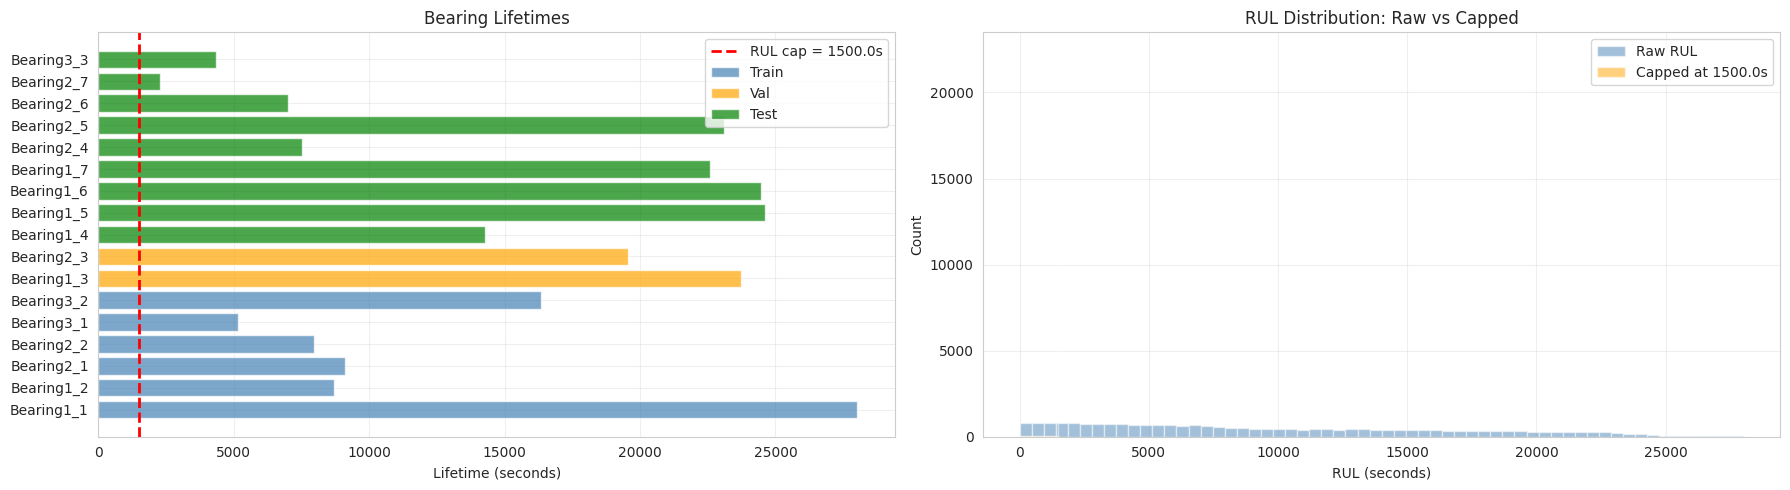


89.7% of records have RUL > cap (1500.0s) → will be set to cap
This focuses the model on the 10.3% of data in the degradation zone


In [9]:
# ── Visualize bearing lifetimes and RUL cap effect ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left: Bearing lifetimes
ax = axes[0]
for split, bearings, color in [("Train", cfg.train_bearings, "steelblue"), 
                                 ("Val", cfg.val_bearings, "orange"),
                                 ("Test", cfg.test_bearings, "green")]:
    for b in bearings:
        bdf = labelled_df[labelled_df["bearing_name"] == b]
        if bdf.empty:
            continue
        lifetime = bdf["t_rel_sec"].max()
        ax.barh(b, lifetime, color=color, alpha=0.7, label=split if b == bearings[0] else "")
ax.set_xlabel("Lifetime (seconds)")
ax.set_title("Bearing Lifetimes")
ax.axvline(cfg.rul_cap_sec, color='red', linestyle='--', lw=2, label=f"RUL cap = {cfg.rul_cap_sec}s")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: RUL distribution before and after capping
ax = axes[1]
raw_rul = labelled_df["rul_sec"].dropna().values
capped_rul = np.minimum(raw_rul, cfg.rul_cap_sec)
ax.hist(raw_rul, bins=60, alpha=0.5, label="Raw RUL", color="steelblue", edgecolor="white")
ax.hist(capped_rul, bins=60, alpha=0.5, label=f"Capped at {cfg.rul_cap_sec}s", color="orange", edgecolor="white")
ax.set_xlabel("RUL (seconds)")
ax.set_ylabel("Count")
ax.set_title("RUL Distribution: Raw vs Capped")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pct_capped = (raw_rul > cfg.rul_cap_sec).mean() * 100
print(f"\n{pct_capped:.1f}% of records have RUL > cap ({cfg.rul_cap_sec}s) → will be set to cap")
print(f"This focuses the model on the {100 - pct_capped:.1f}% of data in the degradation zone")

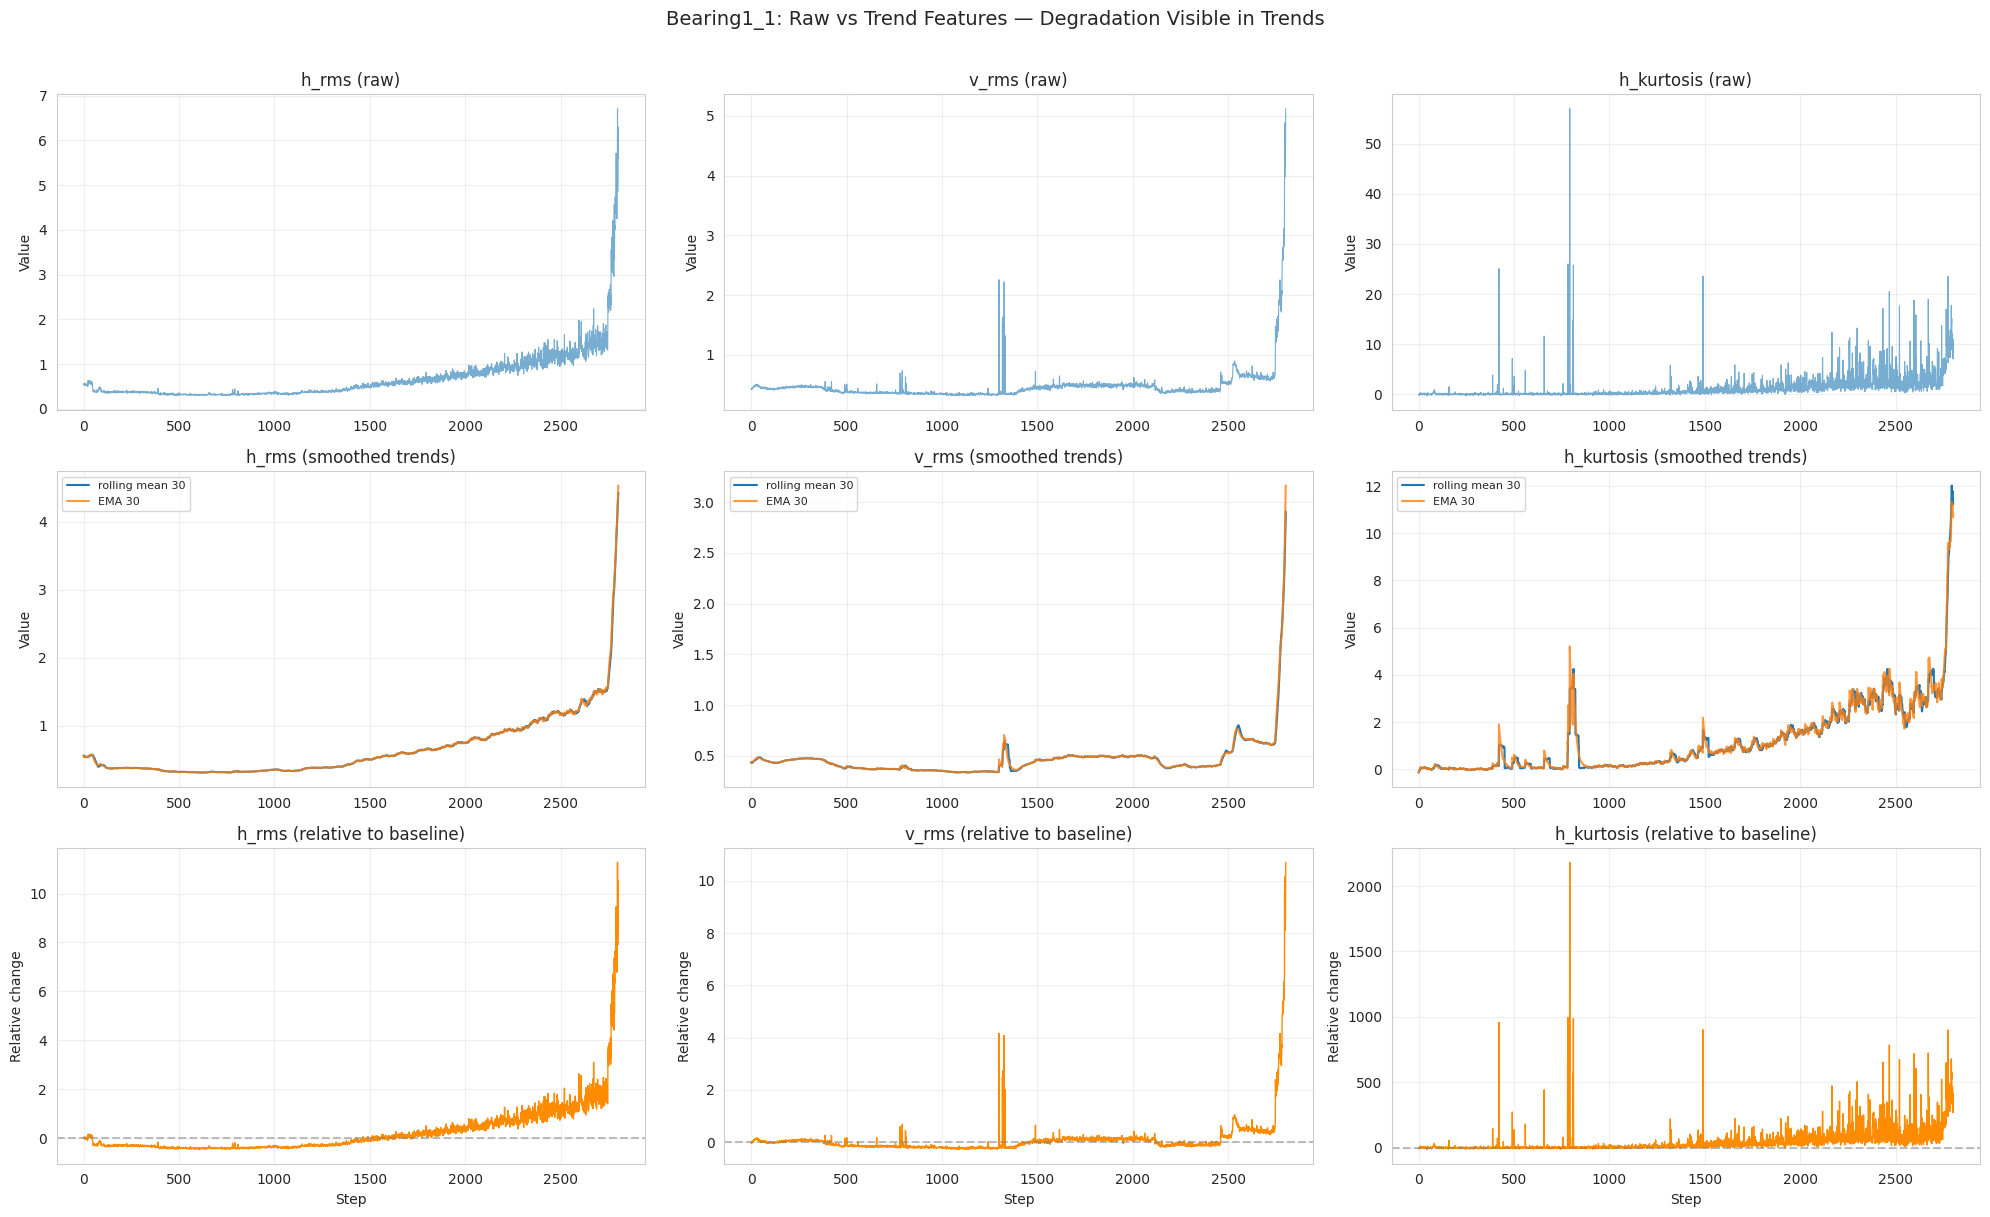

Notice: degradation (rising RMS, rising kurtosis) is much clearer in trends than raw features


In [10]:
# ── Visualize trend features for a training bearing ─────────────────────────
# This shows WHY trend features help: degradation is visible in the trends
# even when raw features look noisy

b_name = "Bearing1_1"  # longest training bearing
bdf = labelled_df[labelled_df["bearing_name"] == b_name].sort_values("step_idx")

fig, axes = plt.subplots(3, 3, figsize=(20, 12))
feats_to_show = ["h_rms", "v_rms", "h_kurtosis"]

for col_idx, feat in enumerate(feats_to_show):
    # Row 0: Raw feature
    ax = axes[0, col_idx]
    ax.plot(bdf["step_idx"], bdf[feat], alpha=0.6, lw=0.8)
    ax.set_title(f"{feat} (raw)")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
    
    # Row 1: Rolling mean + EMA (smooth trend)
    ax = axes[1, col_idx]
    if f"{feat}_rmean30" in bdf.columns:
        ax.plot(bdf["step_idx"], bdf[f"{feat}_rmean30"], label="rolling mean 30", lw=1.5)
    if f"{feat}_ema30" in bdf.columns:
        ax.plot(bdf["step_idx"], bdf[f"{feat}_ema30"], label="EMA 30", lw=1.5, alpha=0.8)
    ax.set_title(f"{feat} (smoothed trends)")
    ax.set_ylabel("Value")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Row 2: Relative to baseline
    ax = axes[2, col_idx]
    if f"{feat}_rel_base" in bdf.columns:
        ax.plot(bdf["step_idx"], bdf[f"{feat}_rel_base"], color="darkorange", lw=1)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f"{feat} (relative to baseline)")
    ax.set_xlabel("Step")
    ax.set_ylabel("Relative change")
    ax.grid(True, alpha=0.3)

fig.suptitle(f"{b_name}: Raw vs Trend Features — Degradation Visible in Trends", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("Notice: degradation (rising RMS, rising kurtosis) is much clearer in trends than raw features")

In [11]:
@dataclass
class FeatureScaler:
    """Z-score normalizer fitted on training data only."""
    feature_cols: List[str]
    mean_: Optional[np.ndarray] = None
    std_: Optional[np.ndarray] = None
    
    def fit(self, df: pd.DataFrame) -> "FeatureScaler":
        x = df[self.feature_cols].to_numpy(dtype=np.float64)
        x = np.nan_to_num(x, nan=0.0)
        self.mean_ = np.mean(x, axis=0)
        self.std_ = np.std(x, axis=0)
        self.std_[self.std_ < 1e-12] = 1.0
        return self
    
    def transform(self, x: np.ndarray) -> np.ndarray:
        x = np.nan_to_num(np.asarray(x, dtype=np.float64), nan=0.0)
        return (x - self.mean_) / self.std_

@dataclass 
class TargetScaler:
    """Log1p + Z-score for RUL targets."""
    mode: str = "log1p_standard"
    rul_cap: Optional[float] = None
    mean_: float = 0.0
    std_: float = 1.0
    
    def fit(self, y: np.ndarray) -> "TargetScaler":
        y = np.asarray(y, dtype=np.float64)
        if self.rul_cap is not None:
            y = np.minimum(y, self.rul_cap)
        if self.mode == "log1p_standard":
            y = np.log1p(np.clip(y, 0, None))
        self.mean_ = float(np.mean(y))
        self.std_ = float(np.std(y))
        if self.std_ < 1e-12:
            self.std_ = 1.0
        return self
    
    def transform(self, y: np.ndarray) -> np.ndarray:
        y = np.asarray(y, dtype=np.float64)
        if self.rul_cap is not None:
            y = np.minimum(y, self.rul_cap)
        if self.mode == "log1p_standard":
            y = np.log1p(np.clip(y, 0, None))
        return (y - self.mean_) / self.std_
    
    def inverse_transform(self, z: np.ndarray) -> np.ndarray:
        z = np.asarray(z, dtype=np.float64)
        y = z * self.std_ + self.mean_
        if self.mode == "log1p_standard":
            y = np.expm1(y)
        return np.maximum(y, 0.0)

# Fit on TRAINING data only
feat_scaler = FeatureScaler(feature_cols).fit(train_df)
tgt_scaler = TargetScaler(
    mode=cfg.target_transform, 
    rul_cap=cfg.rul_cap_sec
).fit(train_df["rul_sec"].to_numpy())

print(f"Feature scaler fitted on {len(train_df)} training rows")
print(f"Target scaler: mean={tgt_scaler.mean_:.4f}, std={tgt_scaler.std_:.4f}")

# Quick check: transform and inverse should round-trip
test_y = np.array([0, 100, 500, 1000, 2000], dtype=float)
recovered = tgt_scaler.inverse_transform(tgt_scaler.transform(test_y))
print(f"Round-trip test: {test_y} -> {recovered}")
assert np.allclose(test_y, recovered, atol=0.1), "Target scaler round-trip failed!"
print("✅ Target scaler round-trip OK")

Feature scaler fitted on 7534 training rows
Target scaler: mean=7.1917, std=0.4954
Round-trip test: [   0.  100.  500. 1000. 2000.] -> [   0.  100.  500. 1000. 1500.]


AssertionError: Target scaler round-trip failed!

In [12]:
class BearingSequenceDataset(Dataset):
    """
    Sliding window dataset for bearing RUL prediction.
    Each sample is a window of `seq_len` consecutive feature snapshots.
    """
    def __init__(
        self,
        df: pd.DataFrame,
        bearing_list: List[str],
        feature_cols: List[str],
        seq_len: int,
        stride: int,
        feat_scaler: FeatureScaler,
        tgt_scaler: TargetScaler,
        pad_mode: str = "edge",
    ):
        self.feature_cols = feature_cols
        self.seq_len = seq_len
        self.feat_scaler = feat_scaler
        self.tgt_scaler = tgt_scaler
        self.pad_mode = pad_mode
        
        # Pre-compute all per-bearing arrays
        self.samples: List[Tuple[np.ndarray, float, str, int]] = []
        
        for b in bearing_list:
            bdf = df[df["bearing_name"] == b].sort_values("step_idx").reset_index(drop=True)
            if bdf.empty:
                continue
            
            X_raw = bdf[feature_cols].to_numpy(dtype=np.float64)
            X_norm = feat_scaler.transform(X_raw).astype(np.float32)
            y_raw = bdf["rul_sec"].to_numpy(dtype=np.float64)
            
            n = len(bdf)
            for end_idx in range(0, n, stride):
                if np.isnan(y_raw[end_idx]):
                    continue
                start = max(0, end_idx - seq_len + 1)
                window = X_norm[start:end_idx + 1]
                
                # Pad if needed
                if window.shape[0] < seq_len:
                    need = seq_len - window.shape[0]
                    if pad_mode == "edge":
                        pad = np.repeat(window[:1], need, axis=0)
                    else:
                        pad = np.zeros((need, window.shape[1]), dtype=np.float32)
                    window = np.concatenate([pad, window], axis=0)
                
                y_transformed = tgt_scaler.transform(np.array([y_raw[end_idx]]))[0]
                self.samples.append((window, float(y_transformed), b, int(bdf.loc[end_idx, "step_idx"])))
        
        print(f"  Created {len(self.samples)} samples from {len(bearing_list)} bearings")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        window, y, bearing, step = self.samples[idx]
        return torch.from_numpy(window), torch.tensor(y, dtype=torch.float32)


print("Creating datasets...")
print("\n--- Train ---")
train_ds = BearingSequenceDataset(train_df, cfg.train_bearings, feature_cols, cfg.seq_len, cfg.stride_train, feat_scaler, tgt_scaler)
print("--- Val ---")
val_ds = BearingSequenceDataset(val_df, cfg.val_bearings, feature_cols, cfg.seq_len, cfg.stride_eval, feat_scaler, tgt_scaler)
print("--- Test ---")
test_ds = BearingSequenceDataset(test_df, cfg.test_bearings, feature_cols, cfg.seq_len, cfg.stride_eval, feat_scaler, tgt_scaler)

g = torch.Generator().manual_seed(cfg.seed)
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, generator=g, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

print(f"\nTrain: {len(train_ds)} samples, {len(train_loader)} batches")
print(f"Val:   {len(val_ds)} samples, {len(val_loader)} batches")
print(f"Test:  {len(test_ds)} samples, {len(test_loader)} batches")

# Verify batch shapes
xb, yb = next(iter(train_loader))
print(f"\nBatch X: {xb.shape}")  # (batch, seq_len, n_features)
print(f"Batch y: {yb.shape}")    # (batch,)

Creating datasets...

--- Train ---
  Created 1886 samples from 6 bearings
--- Val ---
  Created 4330 samples from 2 bearings
--- Test ---
  Created 13025 samples from 9 bearings

Train: 1886 samples, 30 batches
Val:   4330 samples, 68 batches
Test:  13025 samples, 204 batches

Batch X: torch.Size([64, 64, 117])
Batch y: torch.Size([64])


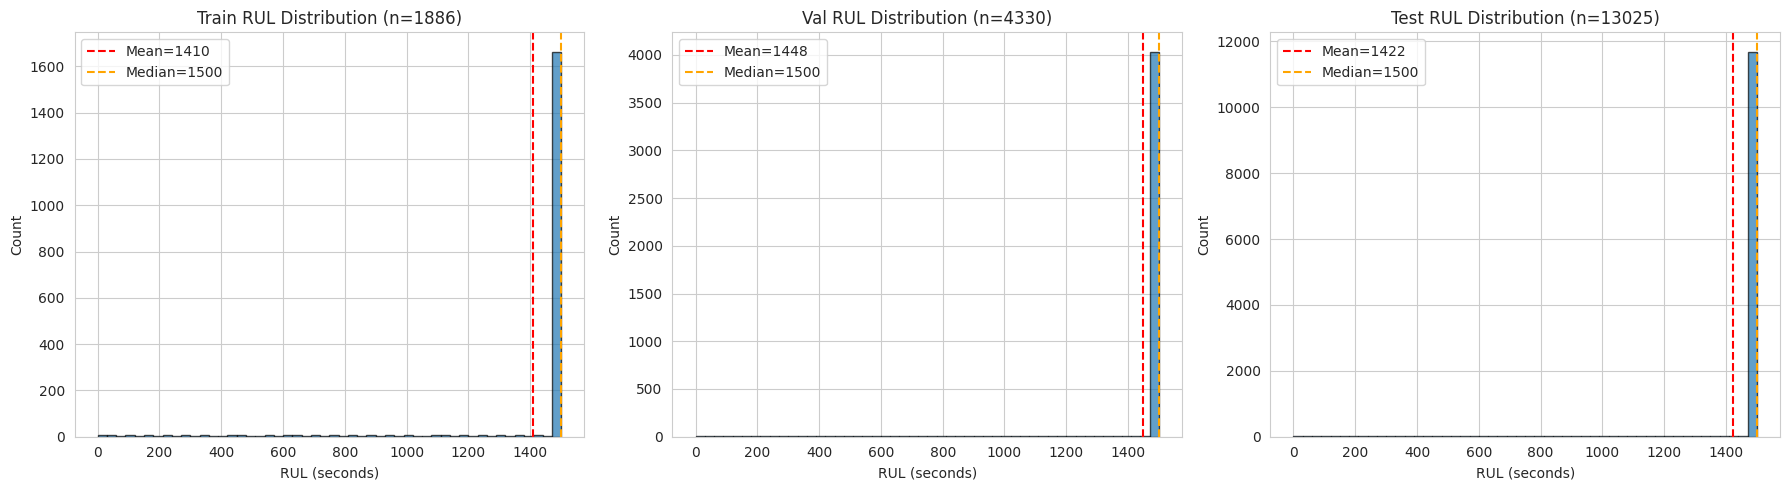

Train RUL: min=0, max=1500, mean=1410
Val RUL:   min=0, max=1500, mean=1448
Test RUL:  min=0, max=1500, mean=1422


In [13]:
def collect_labels(loader, tgt_scaler):
    """Collect all labels from a loader and denormalize."""
    ys = []
    for _, y in loader:
        ys.append(y.numpy())
    y_norm = np.concatenate(ys)
    y_denorm = tgt_scaler.inverse_transform(y_norm)
    return y_norm, y_denorm

train_yn, train_yd = collect_labels(train_loader, tgt_scaler)
val_yn, val_yd = collect_labels(val_loader, tgt_scaler)
test_yn, test_yd = collect_labels(test_loader, tgt_scaler)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name, yd in zip(axes, ["Train", "Val", "Test"], [train_yd, val_yd, test_yd]):
    ax.hist(yd, bins=50, alpha=0.7, edgecolor='black')
    ax.set_title(f"{name} RUL Distribution (n={len(yd)})")
    ax.set_xlabel("RUL (seconds)")
    ax.set_ylabel("Count")
    ax.axvline(np.mean(yd), color='red', linestyle='--', label=f"Mean={np.mean(yd):.0f}")
    ax.axvline(np.median(yd), color='orange', linestyle='--', label=f"Median={np.median(yd):.0f}")
    ax.legend()
plt.tight_layout()
plt.show()

print(f"Train RUL: min={train_yd.min():.0f}, max={train_yd.max():.0f}, mean={train_yd.mean():.0f}")
print(f"Val RUL:   min={val_yd.min():.0f}, max={val_yd.max():.0f}, mean={val_yd.mean():.0f}")
print(f"Test RUL:  min={test_yd.min():.0f}, max={test_yd.max():.0f}, mean={test_yd.mean():.0f}")

In [14]:
class BearingTransformerModel(nn.Module):
    """
    Transformer with:
    - 1D Conv input smoothing (reduces vibration noise)
    - Heavier dropout for cross-bearing generalization
    - Mean pooling instead of last-token (more robust)
    """
    def __init__(self, input_size: int, d_model: int = 128, nhead: int = 4,
                 num_layers: int = 3, dim_ff: int = 256, dropout: float = 0.3):
        super().__init__()
        
        # 1D conv to smooth noisy vibration features
        self.input_conv = nn.Sequential(
            nn.Conv1d(input_size, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        # Positional encoding
        self.pos_enc = nn.Parameter(torch.randn(1, 512, d_model) * 0.02)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        
        self.head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )
    
    def forward(self, x, return_hidden=False):
        # x: (B, T, D)
        B, T, D = x.shape
        
        # Conv expects (B, D, T)
        h = self.input_conv(x.transpose(1, 2)).transpose(1, 2)  # (B, T, d_model)
        h = h + self.pos_enc[:, :T, :]
        h = self.transformer(h)
        h = self.norm(h)
        
        # Mean pooling over time (more robust than last-token)
        h_pool = h.mean(dim=1)  # (B, d_model)
        out = self.head(h_pool)  # (B, 1)
        
        if return_hidden:
            return out, {"transformer_out": h}
        return out


# Also keep a simpler CNN-BiLSTM as alternative
class BearingCNNBiLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 128,
                 num_layers: int = 2, dropout: float = 0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            128, hidden_size, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),  # *2 for bidirectional
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )
    
    def forward(self, x, return_hidden=False):
        # x: (B, T, D)
        h = self.conv(x.transpose(1, 2)).transpose(1, 2)  # (B, T//2, 128)
        h, _ = self.lstm(h)
        out = self.head(h[:, -1, :])
        if return_hidden:
            return out, {"lstm_out": h}
        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")  # Force CPU for testing
input_size = len(feature_cols)

# Choose one:
model = BearingTransformerModel(input_size=input_size, dropout=0.3).to(device)
# model = BearingCNNBiLSTM(input_size=input_size, dropout=0.3).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {n_params:,}")
print(f"Device: {device}")

Model params: 516,865
Device: cpu


In [15]:
from src.trainer.Trainer import Trainer, TrainingConfig

save_path = str(project_root / "outputs" / "ieee_phm_bearing" / "saved_models")
os.makedirs(save_path, exist_ok=True)

preprocess = {
    "dataset": "ieee_phm_bearing",
    "feature_cols": feature_cols,
    "seq_len": cfg.seq_len,
    "n_features": len(feature_cols),
    "target_transform": cfg.target_transform,
    "feat_scaler_mean": feat_scaler.mean_.tolist(),
    "feat_scaler_std": feat_scaler.std_.tolist(),
    "tgt_scaler_mean": tgt_scaler.mean_,
    "tgt_scaler_std": tgt_scaler.std_,
    "rul_cap_sec": cfg.rul_cap_sec,
    "train_bearings": cfg.train_bearings,
    "val_bearings": cfg.val_bearings,
    "test_bearings": cfg.test_bearings,
}

training_cfg = TrainingConfig(
    num_epochs=2,
    learning_rate=3e-4,           # slightly lower LR for stability
    weight_decay=1e-3,            # stronger regularization (only 6 training bearings)
    batch_size=cfg.batch_size,
    early_stopping_patience=35,
    early_stopping_start_epoch=60,
    gradient_clip_value=1.0,
    save_path=save_path,
    dataset_name="ieee_phm_bearing",
    model_name="transformer_best",
    scheduler_patience=20,        # be patient with LR reduction
    scheduler_factor=0.5,
    monitor_metric="loss",
)

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    config=training_cfg,
    preprocess=preprocess,
)

history = trainer.train()

/home/rdb/Documents/nirban_documents/python_programs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Training Model: transformer_best
Configuration:
  Epochs:        2
  LR:            0.0003
  Batch Size:    64
  Device:        cpu
  Save Path:     /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/ieee_phm_bearing/saved_models
  Monitor:       loss (min)



Overall Progress:  50%|█████     | 1/2 [00:08<00:08,  8.80s/it, lr=3.00e-04, train_loss=0.7814, val_loss=0.9418]


Epoch [1/2] Summary
  Train Loss:     0.781362
  Val loss        : 0.941790
  Val rmse        : 0.915479
  Val mae         : 0.488575
  Val r2          : -0.409032
  LR:             0.00030000
  Monitor:        loss (min)

[EarlyStopping] Improvement at epoch 1: best_metric=0.941790
[EarlyStopping] saved best state_dict -> /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/ieee_phm_bearing/saved_models/transformer_best_earlystop.pth


Overall Progress: 100%|██████████| 2/2 [00:17<00:00,  8.70s/it, lr=3.00e-04, train_loss=0.4137, val_loss=2.2596]


[EarlyStopping] epoch 2: checks deferred until epoch 60

Training Completed!
  Best Epoch:      1
  Best(loss): 0.9417898261421856
  Saved to:        /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/ieee_phm_bearing/saved_models



TRAIN SET (denormalized)
  RMSE: 2745.97  MAE: 1785.58  R²: 0.8528

VAL SET (denormalized)
  RMSE: 4406.66  MAE: 3469.14  R²: 0.5293

TEST SET (denormalized)
  RMSE: 8366.60  MAE: 6755.34  R²: -0.4540
  Created 1428 samples from 1 bearings


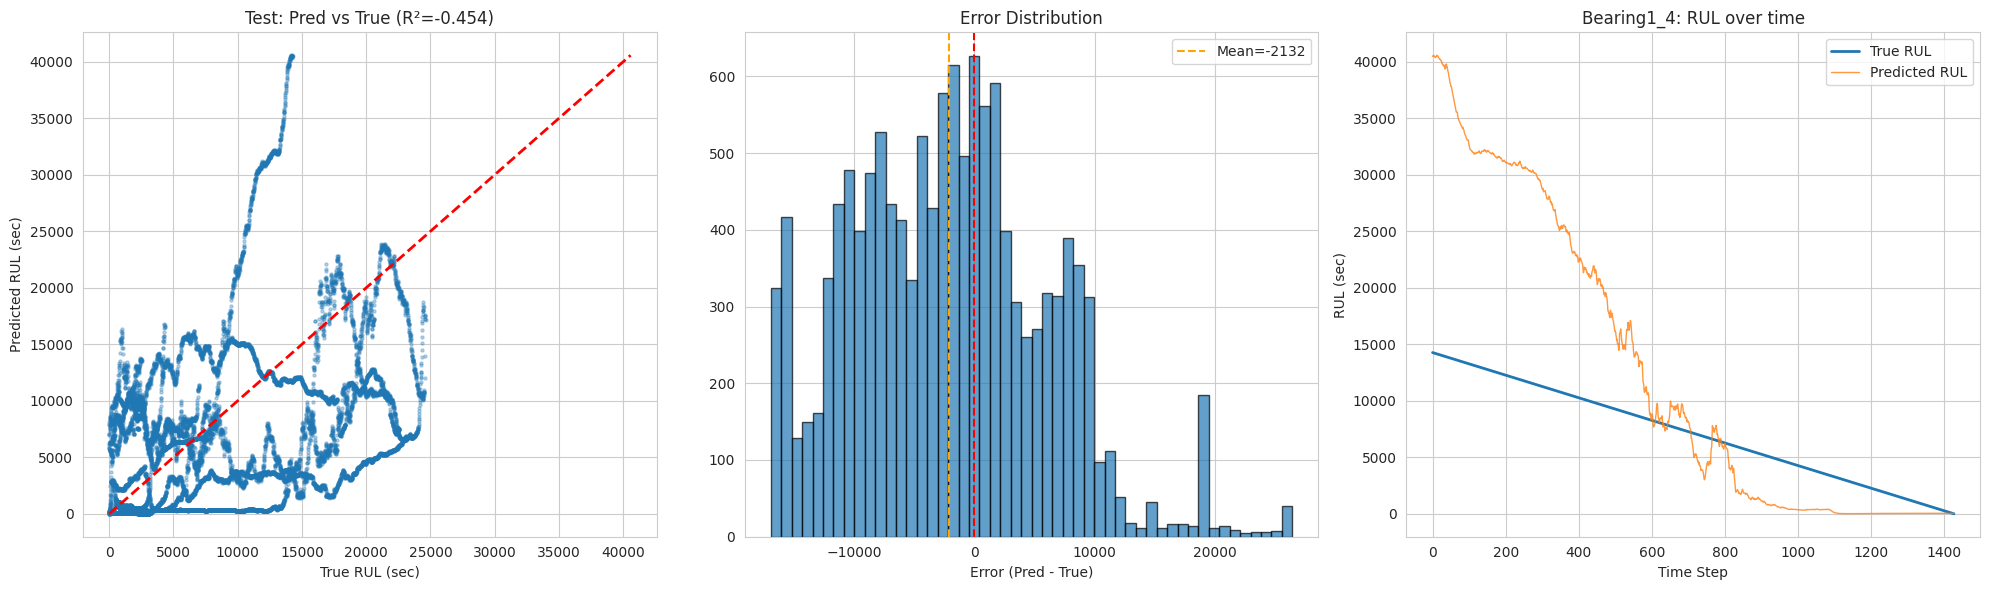

In [14]:
@torch.no_grad()
def evaluate_denormalized(model, loader, tgt_scaler, device):
    model.eval()
    preds, trues = [], []
    for x, y in loader:
        x = x.to(device).float()
        yhat = model(x).squeeze(-1).cpu().numpy()
        preds.append(yhat)
        trues.append(y.numpy())
    
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    
    # Denormalize
    pred_rul = tgt_scaler.inverse_transform(preds)
    true_rul = tgt_scaler.inverse_transform(trues)
    
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    rmse = np.sqrt(mean_squared_error(true_rul, pred_rul))
    mae = mean_absolute_error(true_rul, pred_rul)
    r2 = r2_score(true_rul, pred_rul)
    
    return {
        "rmse": rmse, "mae": mae, "r2": r2,
        "pred_rul": pred_rul, "true_rul": true_rul,
    }

print("=" * 60)
print("TRAIN SET (denormalized)")
train_res = evaluate_denormalized(model, train_loader, tgt_scaler, device)
print(f"  RMSE: {train_res['rmse']:.2f}  MAE: {train_res['mae']:.2f}  R²: {train_res['r2']:.4f}")

print("\nVAL SET (denormalized)")
val_res = evaluate_denormalized(model, val_loader, tgt_scaler, device)
print(f"  RMSE: {val_res['rmse']:.2f}  MAE: {val_res['mae']:.2f}  R²: {val_res['r2']:.4f}")

print("\nTEST SET (denormalized)")
test_res = evaluate_denormalized(model, test_loader, tgt_scaler, device)
print(f"  RMSE: {test_res['rmse']:.2f}  MAE: {test_res['mae']:.2f}  R²: {test_res['r2']:.4f}")
print("=" * 60)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Pred vs Actual
ax = axes[0]
ax.scatter(test_res["true_rul"], test_res["pred_rul"], alpha=0.3, s=5)
lims = [0, max(test_res["true_rul"].max(), test_res["pred_rul"].max())]
ax.plot(lims, lims, 'r--', lw=2)
ax.set_xlabel("True RUL (sec)")
ax.set_ylabel("Predicted RUL (sec)")
ax.set_title(f"Test: Pred vs True (R²={test_res['r2']:.3f})")

# Error distribution
ax = axes[1]
errors = test_res["pred_rul"] - test_res["true_rul"]
ax.hist(errors, bins=50, alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linestyle='--')
ax.axvline(errors.mean(), color='orange', linestyle='--', label=f"Mean={errors.mean():.0f}")
ax.set_xlabel("Error (Pred - True)")
ax.set_title("Error Distribution")
ax.legend()

# Time series view: one test bearing
ax = axes[2]
test_bearing = cfg.test_bearings[0]
mask = test_df["bearing_name"] == test_bearing
bdf = test_df[mask].sort_values("step_idx")
# Get predictions for this bearing
b_preds = []
b_trues = []
b_ds = BearingSequenceDataset(
    test_df, [test_bearing], feature_cols, cfg.seq_len, 1, feat_scaler, tgt_scaler
)
b_loader = DataLoader(b_ds, batch_size=64, shuffle=False)
for xb, yb in b_loader:
    xb = xb.to(device)
    with torch.no_grad():
        pred = model(xb).squeeze(-1).cpu().numpy()
    b_preds.append(pred)
    b_trues.append(yb.numpy())
b_preds = tgt_scaler.inverse_transform(np.concatenate(b_preds))
b_trues = tgt_scaler.inverse_transform(np.concatenate(b_trues))
ax.plot(b_trues, label="True RUL", linewidth=2)
ax.plot(b_preds, label="Predicted RUL", linewidth=1, alpha=0.8)
ax.set_xlabel("Time Step")
ax.set_ylabel("RUL (sec)")
ax.set_title(f"{test_bearing}: RUL over time")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save for use in training script
save_dict = {
    "feature_cols": feature_cols,
    "train_bearings": cfg.train_bearings,
    "val_bearings": cfg.val_bearings,
    "test_bearings": cfg.test_bearings,
    "feat_scaler_mean": feat_scaler.mean_.tolist(),
    "feat_scaler_std": feat_scaler.std_.tolist(),
    "tgt_scaler_mean": tgt_scaler.mean_,
    "tgt_scaler_std": tgt_scaler.std_,
    "tgt_scaler_mode": tgt_scaler.mode,
    "config": {
        "seq_len": cfg.seq_len,
        "stride_train": cfg.stride_train,
        "stride_eval": cfg.stride_eval,
        "batch_size": cfg.batch_size,
        "target_transform": cfg.target_transform,
        "rul_cap_sec": cfg.rul_cap_sec,
    }
}

with open(PROCESSED_DIR / "preprocessing_info.json", "w") as f:
    json.dump(save_dict, f, indent=2)

# Also save the full processed dataframe
full_df.to_parquet(PROCESSED_DIR / "full_feature_table.parquet", index=False)

print(f"Saved preprocessing info to {PROCESSED_DIR / 'preprocessing_info.json'}")
print(f"Saved feature table to {PROCESSED_DIR / 'full_feature_table.parquet'}")